# 01 - Dataset Exploration

Este notebook sirve para **explorar, validar y justificar** el uso del dataset para un modelo de Threat Hunting orientado a SOC.

No se entrena el modelo todavía. El objetivo es entender qué contiene el archivo raw, identificar calidad de datos, distribución de clases, patrones por tipo de ataque y variables candidatas para el entrenamiento.

## Entrada

```text
../data/raw/cicids2017_original.csv
```

## Salida esperada

Este notebook no genera un modelo. Genera evidencia para decidir cómo preparar el dataset en el siguiente notebook:

```text
02_preprocessing.ipynb
```

## Secciones

1. Configuración inicial.
2. Carga del dataset.
3. Tamaño del dataset.
4. Columnas disponibles.
5. Tipos de datos.
6. Valores nulos.
7. Valores infinitos.
8. Distribución de etiquetas.
9. Estadístico general.
10. Gráfico de etiquetas.
11. Distribución porcentual de etiquetas.
12. Comparación BENIGN vs MALICIOUS.
13. Estadísticas por tipo de ataque.
14. Revisión de outliers.
15. Correlación entre variables numéricas.
16. Conclusiones para preprocesamiento.


## 1. Configuración inicial

In [4]:
# Importamos las librerías necesarias para análisis exploratorio.
# pandas: manipulación de datos.
# numpy: operaciones numéricas.
# matplotlib: gráficos.
# pathlib: manejo de rutas.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Ruta del dataset raw.
# En Colab, si trabajas desde Drive, puedes cambiar esta ruta por:
# DATASET_PATH = "/content/drive/MyDrive/threat-hunting-soc-ai/data/raw/cicids2017_original.csv"
# En local: DATASET_PATH = "../data/raw/cicids2017_original.csv"

DATASET_PATH = Path("/content/drive/MyDrive/Proyecto final/threat-hunting-soc-ai/data/raw/cicids2017_original.csv")

# Configuración para visualizar mejor las tablas.
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Dataset path:", DATASET_PATH)
print("Exists:", DATASET_PATH.exists())

Dataset path: /content/drive/MyDrive/Proyecto final/threat-hunting-soc-ai/data/raw/cicids2017_original.csv
Exists: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Cargar dataset original

In [5]:
# Cargamos el archivo CSV original.
# Cada fila representa un flujo/evento de red.

df = pd.read_csv(DATASET_PATH)

# Mostramos las primeras filas para validar estructura y valores.
df.head()

,Timestamp,Source IP,Destination IP,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,Label
0,2026-06-20 08:14:20,192.168.2.108,81.188.20.104,7289,443,6,1009890,77,25,8472,1785,10156.5517,101.0011,100.5588,35.8378,1,1,1,3,12,BENIGN
1,2026-06-20 13:48:59,192.168.1.23,98.48.218.60,19966,25,6,1443257,62,16,339,19218,13550.6012,54.0444,250.7308,84.5561,1,2,1,2,4,BENIGN
2,2026-06-20 11:09:54,192.168.0.52,144.20.72.168,22801,248,6,11127,1,3,53,241,26422.2162,359.4859,73.5000,24.9005,1,6,4,0,3,PortScan
3,2026-06-20 15:32:12,192.168.3.176,44.205.80.165,2609,443,6,1783415,6,3,1171,11753,7246.7709,5.0465,1436.0000,498.7867,1,1,1,1,13,BENIGN
4,2026-06-20 09:54:33,192.168.3.163,211.189.227.15,33630,22,6,585822,81,85,27851,3016,52690.0663,283.3625,185.9458,69.0006,1,14,8,15,52,SSH-Patator


## 3. Tamaño del dataset

In [6]:
# Revisamos la cantidad de filas y columnas.
# Esto permite saber el volumen inicial de datos disponible.

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1000
Columns: 21


## 4. Columnas disponibles

In [7]:
# Listamos las columnas disponibles.
# Esto ayuda a identificar qué variables podrían alimentar el modelo.

df.columns.tolist()

['Timestamp',
 'Source IP',
 'Destination IP',
 'Source Port',
 'Destination Port',
 'Protocol',
 'Flow Duration',
 'Total Fwd Packets',
 'Total Backward Packets',
 'Total Length of Fwd Packets',
 'Total Length of Bwd Packets',
 'Flow Bytes/s',
 'Flow Packets/s',
 'Packet Length Mean',
 'Packet Length Std',
 'FIN Flag Count',
 'SYN Flag Count',
 'RST Flag Count',
 'PSH Flag Count',
 'ACK Flag Count',
 'Label']

## 5. Tipos de datos

In [8]:
# Revisamos el tipo de dato de cada columna.
# Es importante para saber qué columnas son numéricas, categóricas o fechas.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Timestamp                    1000 non-null   object 
 1   Source IP                    1000 non-null   object 
 2   Destination IP               1000 non-null   object 
 3   Source Port                  1000 non-null   int64  
 4   Destination Port             1000 non-null   int64  
 5   Protocol                     1000 non-null   int64  
 6   Flow Duration                1000 non-null   int64  
 7   Total Fwd Packets            1000 non-null   int64  
 8   Total Backward Packets       1000 non-null   int64  
 9   Total Length of Fwd Packets  1000 non-null   int64  
 10  Total Length of Bwd Packets  1000 non-null   int64  
 11  Flow Bytes/s                 1000 non-null   float64
 12  Flow Packets/s               1000 non-null   float64
 13  Packet Length Mean 

## 6. Revisión de valores nulos

In [9]:
# Revisamos valores nulos por columna.
# Los nulos deben limpiarse o imputarse antes del entrenamiento.

null_values = df.isnull().sum().sort_values(ascending=False)
null_values[null_values > 0]

,0


## 7. Revisión de valores infinitos

In [10]:
# Revisamos valores infinitos en columnas numéricas.
# Algunos datasets de tráfico pueden tener infinitos en ratios como Flow Bytes/s.
# Estos valores deben reemplazarse antes de entrenar.

numeric_df = df.select_dtypes(include=[np.number])
infinite_values = np.isinf(numeric_df).sum().sort_values(ascending=False)

infinite_values[infinite_values > 0]

,0


## 8. Distribución de etiquetas

In [11]:
# Revisamos cuántos registros existen por etiqueta.
# Esto permite ver qué tipos de tráfico o ataques existen en el dataset.

label_counts = df["Label"].value_counts()
label_counts

,count
Label,
BENIGN,543
PortScan,123
DDoS,92
DoS Hulk,90
Bot,71
SSH-Patator,47
FTP-Patator,34


## 9. Estadístico general

In [12]:
# Generamos estadísticos generales de las variables numéricas.
# Esto ayuda a detectar rangos, promedios, dispersión y valores extremos.

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Source Port,1000.0,3.200501e+04,1.827398e+04,1183.0000,16908.00000,31236.00000,4.706875e+04,6.533900e+04
Destination Port,1000.0,1.014663e+03,2.203877e+03,21.0000,53.00000,143.00000,8.485000e+02,8.080000e+03
Protocol,1000.0,8.838000e+00,4.815282e+00,6.0000,6.00000,6.00000,1.700000e+01,1.700000e+01
Flow Duration,1000.0,9.058597e+05,1.212367e+06,1399.0000,159432.75000,521339.00000,1.316220e+06,7.985727e+06
Total Fwd Packets,1000.0,1.070640e+02,1.572361e+02,1.0000,19.00000,53.00000,8.175000e+01,7.880000e+02
Total Backward Packets,1000.0,4.000500e+01,3.827639e+01,0.0000,12.00000,31.00000,5.800000e+01,2.190000e+02
Total Length of Fwd Packets,1000.0,9.483621e+04,1.913806e+05,41.0000,5824.75000,15915.50000,3.892975e+04,8.966260e+05
Total Length of Bwd Packets,1000.0,2.428267e+04,3.404831e+04,0.0000,5682.75000,17469.00000,2.618950e+04,2.197130e+05
Flow Bytes/s,1000.0,1.061439e+06,6.992433e+06,1209.8801,21004.63870,43959.40895,2.129427e+05,2.011280e+08
Flow Packets/s,1000.0,1.268754e+03,8.521238e+03,5.0465,64.60995,141.08795,5.714841e+02,2.434494e+05


## 10. Gráfico de distribución de etiquetas

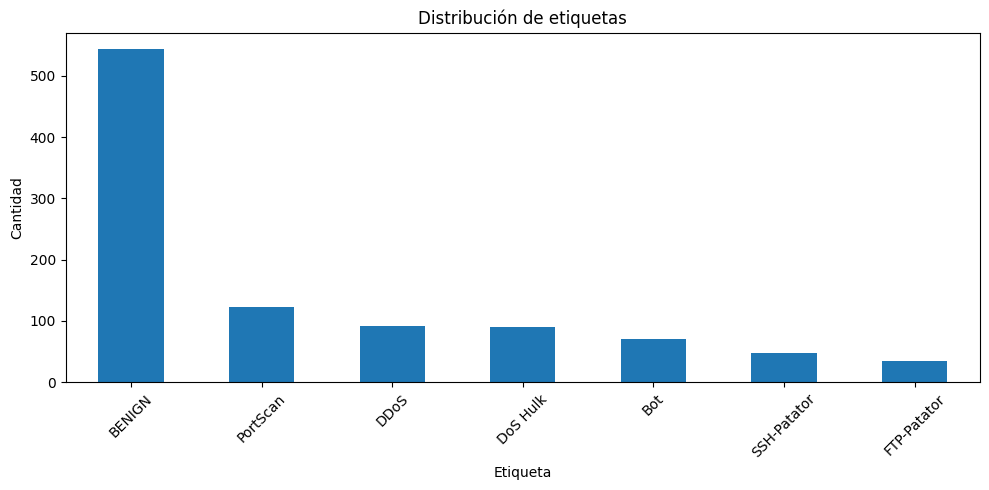

In [13]:
# Graficamos la cantidad de registros por etiqueta.
# Permite ver rápidamente si hay clases dominantes o clases minoritarias.

plt.figure(figsize=(10, 5))
label_counts.plot(kind="bar")
plt.title("Distribución de etiquetas")
plt.xlabel("Etiqueta")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Distribución porcentual de etiquetas

Esta sección muestra qué porcentaje representa cada clase dentro del dataset.

Sirve para detectar **desbalance de clases**. En Threat Hunting esto es importante porque un modelo puede obtener buen accuracy prediciendo la clase dominante, pero fallar detectando ataques.

In [14]:
# Calculamos cantidad y porcentaje por etiqueta.
# normalize=True convierte los conteos en proporciones.

label_counts = df["Label"].value_counts()
label_percentages = df["Label"].value_counts(normalize=True) * 100

label_distribution = pd.DataFrame({
    "count": label_counts,
    "percentage": label_percentages.round(2)
})

label_distribution

,count,percentage
Label,,
BENIGN,543,54.3
PortScan,123,12.3
DDoS,92,9.2
DoS Hulk,90,9.0
Bot,71,7.1
SSH-Patator,47,4.7
FTP-Patator,34,3.4


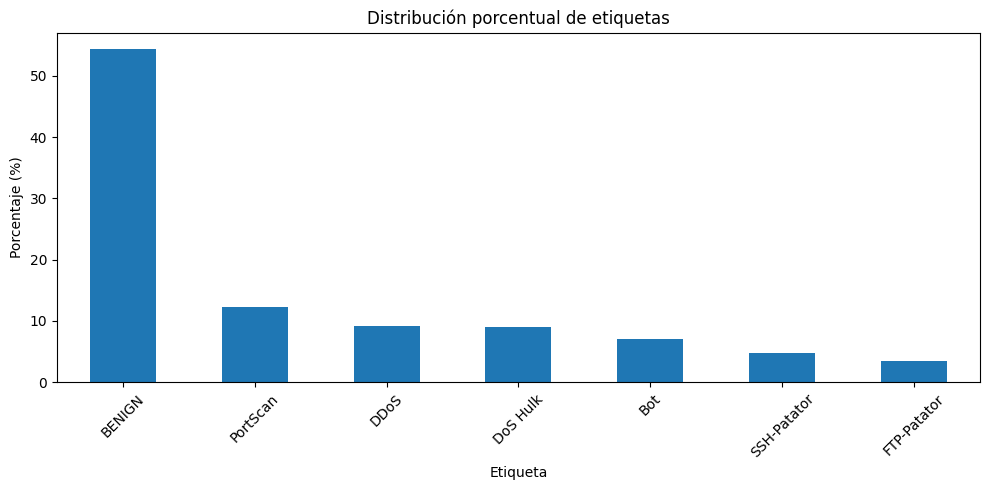

In [15]:
# Graficamos la distribución porcentual.
# Esto permite visualizar el peso relativo de cada clase.

plt.figure(figsize=(10, 5))
label_percentages.plot(kind="bar")
plt.title("Distribución porcentual de etiquetas")
plt.xlabel("Etiqueta")
plt.ylabel("Porcentaje (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusión de la sección

Si una clase como `BENIGN` tiene mucho más peso que las clases de ataque, se debe considerar:

- `class_weight="balanced"` en modelos tradicionales.
- Oversampling o undersampling.
- Evaluar con precision, recall y F1-score.
- No depender solo de accuracy.


## 12. Comparación BENIGN vs MALICIOUS

Para el primer MVP conviene simplificar el problema a clasificación binaria:

```text
BENIGN vs MALICIOUS
```

Así el primer modelo responde una pregunta directa para SOC:

> ¿Este evento parece normal o sospechoso?


In [16]:
# Creamos una etiqueta binaria.
# Si la etiqueta original es BENIGN, se mantiene como BENIGN.
# Todo lo demás se considera MALICIOUS.

df["Binary Label"] = df["Label"].apply(
    lambda value: "BENIGN" if value == "BENIGN" else "MALICIOUS"
)

binary_counts = df["Binary Label"].value_counts()
binary_percentages = df["Binary Label"].value_counts(normalize=True) * 100

binary_distribution = pd.DataFrame({
    "count": binary_counts,
    "percentage": binary_percentages.round(2)
})

binary_distribution

,count,percentage
Binary Label,,
BENIGN,543,54.3
MALICIOUS,457,45.7


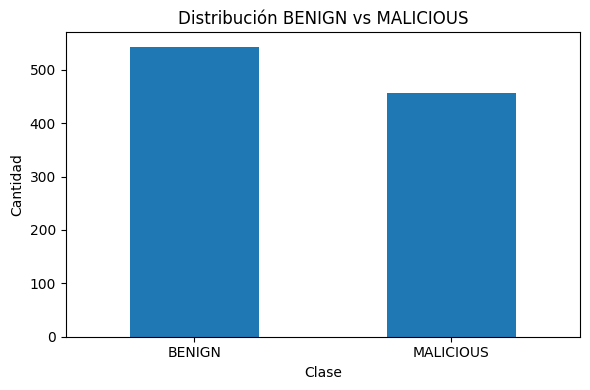

In [17]:
# Graficamos BENIGN vs MALICIOUS.
# Esto permite revisar si hay suficiente tráfico malicioso para entrenar.

plt.figure(figsize=(6, 4))
binary_counts.plot(kind="bar")
plt.title("Distribución BENIGN vs MALICIOUS")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
# Seleccionamos columnas relevantes para comparar tráfico benigno y malicioso.
# Estas variables representan duración, volumen, velocidad y flags TCP.

columns_to_compare = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "Packet Length Std",
    "SYN Flag Count",
    "ACK Flag Count",
    "RST Flag Count"
]

# Calculamos el promedio de cada variable por clase binaria.
# Esto ayuda a detectar diferencias entre tráfico normal y sospechoso.

binary_comparison = df.groupby("Binary Label")[columns_to_compare].mean().round(2)
binary_comparison

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,SYN Flag Count,ACK Flag Count,RST Flag Count
Binary Label,,,,,,,,,,,,
BENIGN,996835.10,42.78,35.94,12552.82,15983.55,80899.66,233.51,472.96,164.62,1.54,7.87,0.50
MALICIOUS,797764.12,183.44,44.83,192604.01,34143.55,2226499.57,2498.81,900.59,323.84,40.15,43.57,4.07


### Conclusión de la sección

Si `MALICIOUS` muestra valores más altos en variables como `Flow Bytes/s`, `Flow Packets/s`, `Total Fwd Packets` o `SYN Flag Count`, esas variables son buenas candidatas para alimentar el modelo.


## 13. Estadísticas agrupadas por tipo de ataque

Esta sección compara el comportamiento promedio por clase original:

- BENIGN
- PortScan
- DDoS
- DoS Hulk
- Bot
- SSH-Patator
- FTP-Patator

Sirve para justificar qué variables diferencian cada tipo de ataque.


In [19]:
# Agrupamos por Label y calculamos el promedio de variables relevantes.
# Esto permite crear un perfil básico por tipo de ataque.

attack_profile = df.groupby("Label")[columns_to_compare].mean().round(2)

attack_profile

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,SYN Flag Count,ACK Flag Count,RST Flag Count
Label,,,,,,,,,,,,
BENIGN,996835.10,42.78,35.94,12552.82,15983.55,80899.66,233.51,472.96,164.62,1.54,7.87,0.50
Bot,4051732.25,133.66,124.34,90728.55,117509.94,90579.00,113.17,974.54,362.99,11.27,100.18,2.73
DDoS,136787.03,428.17,15.62,490537.05,15239.72,7873645.28,8201.25,1598.06,566.57,103.62,39.24,3.48
DoS Hulk,299979.54,325.13,44.22,383400.44,36484.93,2957228.74,3088.33,1601.78,579.85,67.02,52.44,4.47
FTP-Patator,347197.29,63.91,66.44,20305.88,29901.03,227186.02,603.20,462.30,157.08,14.62,47.76,4.76
PortScan,28571.62,4.39,1.67,322.41,144.26,32569.98,490.25,105.51,36.92,7.16,1.98,4.53
SSH-Patator,468162.34,63.32,80.36,25804.30,32772.77,187719.34,439.33,478.69,170.81,12.87,55.34,4.74


In [20]:
# Ordenamos por Flow Bytes/s.
# Esto ayuda a identificar ataques de alto volumen, por ejemplo DoS o DDoS.

attack_profile.sort_values(by="Flow Bytes/s", ascending=False)

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,SYN Flag Count,ACK Flag Count,RST Flag Count
Label,,,,,,,,,,,,
DDoS,136787.03,428.17,15.62,490537.05,15239.72,7873645.28,8201.25,1598.06,566.57,103.62,39.24,3.48
DoS Hulk,299979.54,325.13,44.22,383400.44,36484.93,2957228.74,3088.33,1601.78,579.85,67.02,52.44,4.47
FTP-Patator,347197.29,63.91,66.44,20305.88,29901.03,227186.02,603.20,462.30,157.08,14.62,47.76,4.76
SSH-Patator,468162.34,63.32,80.36,25804.30,32772.77,187719.34,439.33,478.69,170.81,12.87,55.34,4.74
Bot,4051732.25,133.66,124.34,90728.55,117509.94,90579.00,113.17,974.54,362.99,11.27,100.18,2.73
BENIGN,996835.10,42.78,35.94,12552.82,15983.55,80899.66,233.51,472.96,164.62,1.54,7.87,0.50
PortScan,28571.62,4.39,1.67,322.41,144.26,32569.98,490.25,105.51,36.92,7.16,1.98,4.53


In [21]:
# Ordenamos por SYN Flag Count.
# Esto ayuda a identificar patrones de conexión repetida, escaneo o floods.

attack_profile.sort_values(by="SYN Flag Count", ascending=False)

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,SYN Flag Count,ACK Flag Count,RST Flag Count
Label,,,,,,,,,,,,
DDoS,136787.03,428.17,15.62,490537.05,15239.72,7873645.28,8201.25,1598.06,566.57,103.62,39.24,3.48
DoS Hulk,299979.54,325.13,44.22,383400.44,36484.93,2957228.74,3088.33,1601.78,579.85,67.02,52.44,4.47
FTP-Patator,347197.29,63.91,66.44,20305.88,29901.03,227186.02,603.20,462.30,157.08,14.62,47.76,4.76
SSH-Patator,468162.34,63.32,80.36,25804.30,32772.77,187719.34,439.33,478.69,170.81,12.87,55.34,4.74
Bot,4051732.25,133.66,124.34,90728.55,117509.94,90579.00,113.17,974.54,362.99,11.27,100.18,2.73
PortScan,28571.62,4.39,1.67,322.41,144.26,32569.98,490.25,105.51,36.92,7.16,1.98,4.53
BENIGN,996835.10,42.78,35.94,12552.82,15983.55,80899.66,233.51,472.96,164.62,1.54,7.87,0.50


### Conclusión de la sección

El análisis por tipo de ataque ayuda a identificar patrones:

- Ataques volumétricos suelen aumentar bytes, paquetes o tasas por segundo.
- Ataques de reconocimiento pueden reflejarse en puertos o flags TCP.
- Botnets pueden tener flujos más persistentes o patrones de comunicación repetidos.

Esta información justifica la selección de variables para el modelo.


## 14. Revisión de outliers

Los outliers son valores extremos.

En ciberseguridad no siempre deben eliminarse, porque pueden representar ataques reales. Sin embargo, sí deben manejarse con escalamiento o transformación para evitar que afecten el entrenamiento.


In [22]:
# Definimos columnas donde esperamos posibles valores extremos.
# Estas columnas tienen diferentes escalas y pueden representar anomalías.

outlier_columns = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Total Length of Fwd Packets",
    "Total Length of Bwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "Packet Length Std",
    "SYN Flag Count",
    "ACK Flag Count"
]

# Resumen estadístico enfocado en estas columnas.
df[outlier_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Duration,1000.0,9.058597e+05,1.212367e+06,1399.0000,159432.75000,521339.00000,1.316220e+06,7.985727e+06
Total Fwd Packets,1000.0,1.070640e+02,1.572361e+02,1.0000,19.00000,53.00000,8.175000e+01,7.880000e+02
Total Backward Packets,1000.0,4.000500e+01,3.827639e+01,0.0000,12.00000,31.00000,5.800000e+01,2.190000e+02
Total Length of Fwd Packets,1000.0,9.483621e+04,1.913806e+05,41.0000,5824.75000,15915.50000,3.892975e+04,8.966260e+05
Total Length of Bwd Packets,1000.0,2.428267e+04,3.404831e+04,0.0000,5682.75000,17469.00000,2.618950e+04,2.197130e+05
Flow Bytes/s,1000.0,1.061439e+06,6.992433e+06,1209.8801,21004.63870,43959.40895,2.129427e+05,2.011280e+08
Flow Packets/s,1000.0,1.268754e+03,8.521238e+03,5.0465,64.60995,141.08795,5.714841e+02,2.434494e+05
Packet Length Mean,1000.0,6.683880e+02,9.187216e+02,9.0000,226.70190,394.16070,7.309182e+02,9.862697e+03
Packet Length Std,1000.0,2.373846e+02,3.551767e+02,2.2550,73.33150,133.89955,2.467031e+02,5.384606e+03
SYN Flag Count,1000.0,1.918200e+01,3.758363e+01,0.0000,1.00000,3.00000,1.300000e+01,1.900000e+02


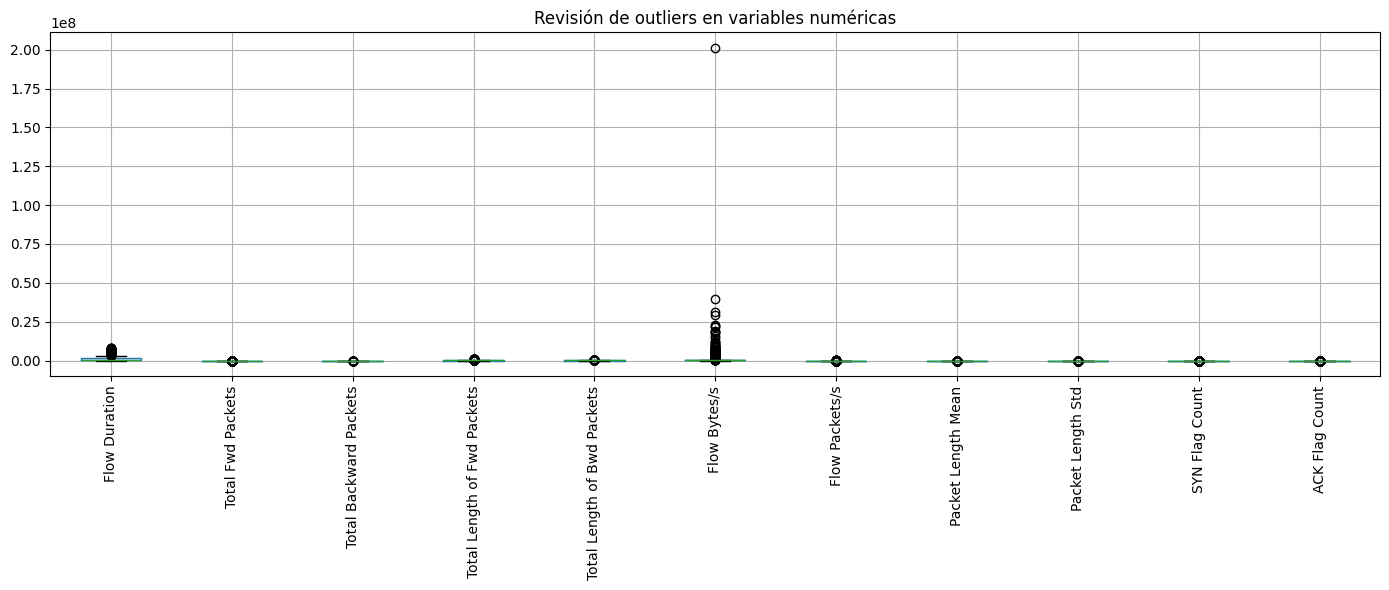

In [23]:
# Boxplot de variables numéricas.
# Si algunas variables tienen escala muy alta, el gráfico puede verse comprimido.
# Eso confirma la necesidad de escalamiento o transformación.

plt.figure(figsize=(14, 6))
df[outlier_columns].boxplot()
plt.title("Revisión de outliers en variables numéricas")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [24]:
# Aplicamos transformación logarítmica a variables muy dispersas.
# np.log1p(x) calcula log(1 + x), por eso no falla cuando x = 0.
# Esto reduce el impacto visual y estadístico de valores extremos.

log_columns = [
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "SYN Flag Count"
]

df_log = df.copy()

for column in log_columns:
    df_log[column + " Log"] = np.log1p(df_log[column])

log_transformed_columns = [column + " Log" for column in log_columns]

df_log[log_transformed_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Flow Bytes/s Log,1000.0,11.308493,1.980247,7.099103,9.952546,10.691044,12.268782,19.119452
Flow Packets/s Log,1000.0,5.357519,1.591997,1.799480,4.183727,4.956446,6.349982,12.402669
Flow Duration Log,1000.0,12.843154,1.591032,7.244228,11.979384,13.164093,14.090275,15.893167
Total Fwd Packets Log,1000.0,3.844159,1.361145,0.693147,2.995732,3.988984,4.415702,6.670766
Total Length of Fwd Packets Log,1000.0,9.584353,2.187398,3.737670,8.670031,9.675108,10.569540,13.706395
SYN Flag Count Log,1000.0,1.840375,1.422445,0.000000,0.693147,1.386294,2.639057,5.252273


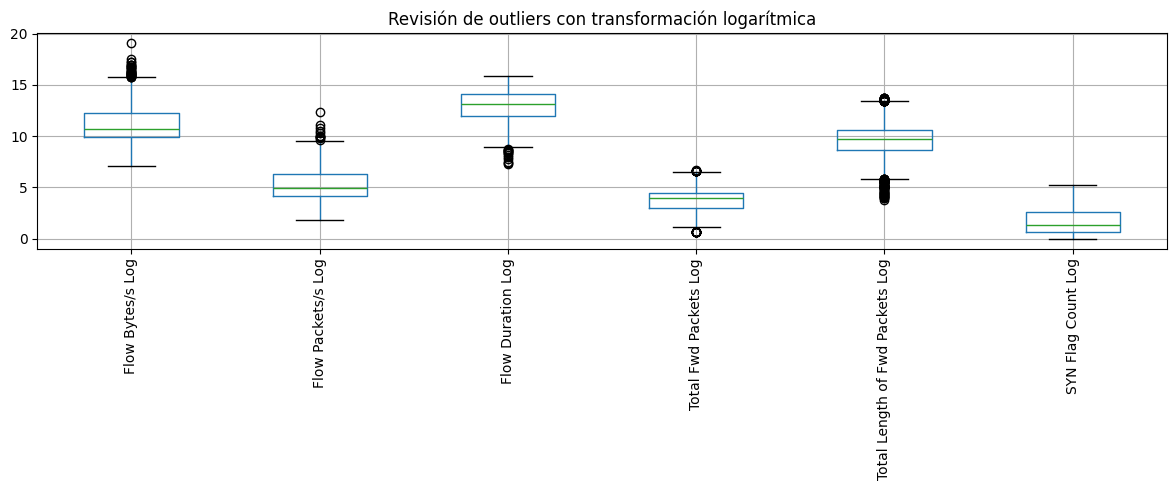

In [25]:
# Boxplot con transformación logarítmica.
# Permite observar mejor la distribución cuando existen valores extremos.

plt.figure(figsize=(12, 5))
df_log[log_transformed_columns].boxplot()
plt.title("Revisión de outliers con transformación logarítmica")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Conclusión de la sección

Los valores extremos no deben eliminarse automáticamente porque pueden representar tráfico malicioso. Para el entrenamiento se recomienda:

- Reemplazar infinitos.
- Rellenar o tratar nulos.
- Aplicar `StandardScaler` o `RobustScaler`.
- Evaluar transformación `log1p` en variables muy dispersas.


## 15. Correlación entre variables numéricas

La correlación ayuda a detectar variables que se comportan de forma parecida.

Si dos variables tienen correlación muy alta, podrían aportar información redundante al modelo.


In [26]:
# Calculamos matriz de correlación solo con variables numéricas.
# Valores cercanos a 1 indican correlación positiva fuerte.
# Valores cercanos a -1 indican correlación negativa fuerte.
# Valores cercanos a 0 indican baja relación lineal.

numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

correlation_matrix.round(2)

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count
Source Port,1.00,-0.01,0.00,-0.03,-0.04,-0.05,-0.05,-0.04,-0.06,-0.05,-0.03,-0.03,-0.01,-0.05,-0.01,-0.03,-0.06
Destination Port,-0.01,1.00,-0.04,0.16,0.32,0.17,0.30,0.26,0.07,0.07,0.18,0.17,0.16,0.30,0.18,0.43,0.35
Protocol,0.00,-0.04,1.00,0.02,0.02,-0.01,0.02,0.05,-0.01,-0.00,0.02,0.03,-0.03,0.00,-0.01,0.00,-0.00
Flow Duration,-0.03,0.16,0.02,1.00,-0.10,0.51,-0.15,0.54,-0.10,-0.10,0.00,0.00,0.10,-0.22,-0.15,0.26,0.42
Total Fwd Packets,-0.04,0.32,0.02,-0.10,1.00,0.01,0.71,0.12,0.33,0.33,0.16,0.15,0.10,0.70,0.25,0.46,0.35
Total Backward Packets,-0.05,0.17,-0.01,0.51,0.01,1.00,-0.04,0.59,-0.04,-0.03,-0.06,-0.06,0.20,-0.11,0.01,0.42,0.48
Total Length of Fwd Packets,-0.05,0.30,0.02,-0.15,0.71,-0.04,1.00,0.08,0.32,0.22,0.62,0.58,0.07,0.72,0.30,0.44,0.32
Total Length of Bwd Packets,-0.04,0.26,0.05,0.54,0.12,0.59,0.08,1.00,-0.02,-0.03,0.24,0.24,0.22,0.02,0.08,0.52,0.60
Flow Bytes/s,-0.06,0.07,-0.01,-0.10,0.33,-0.04,0.32,-0.02,1.00,0.98,0.13,0.13,-0.01,0.27,0.12,0.12,0.08
Flow Packets/s,-0.05,0.07,-0.00,-0.10,0.33,-0.03,0.22,-0.03,0.98,1.00,0.03,0.04,-0.01,0.22,0.12,0.10,0.07


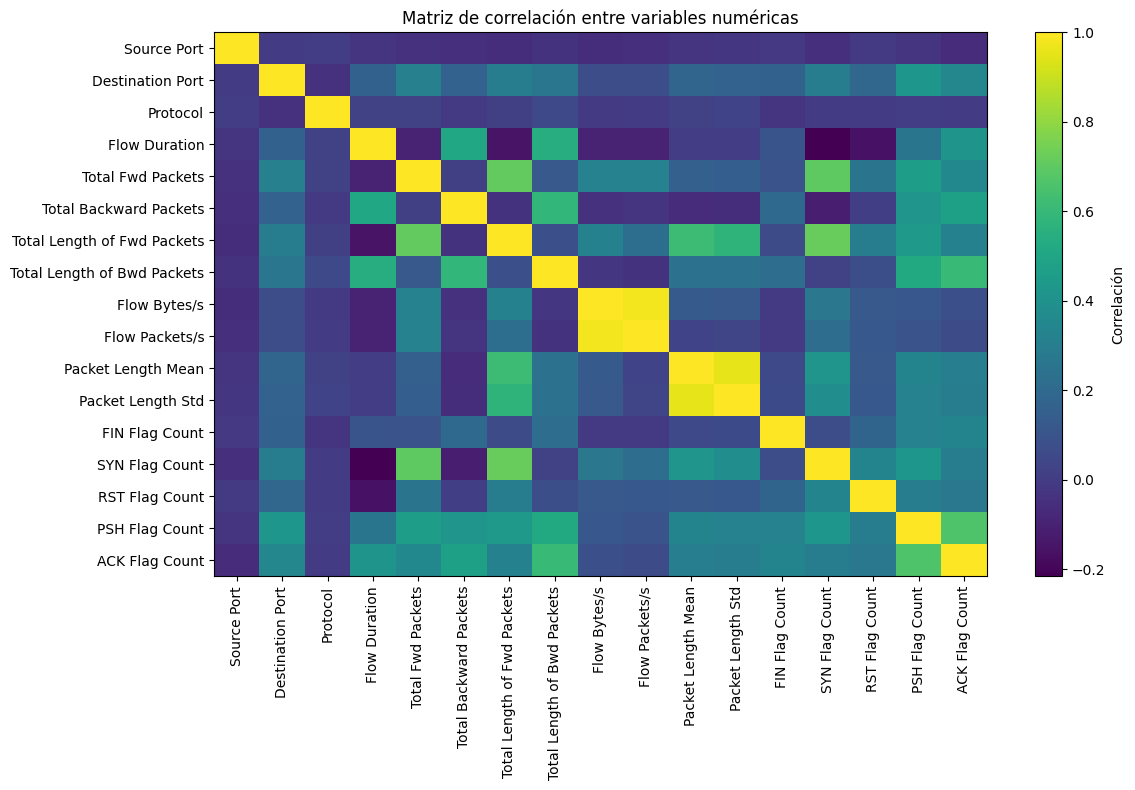

In [27]:
# Mapa de calor de correlación usando matplotlib.
# No usamos seaborn para mantener dependencias simples.

plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlación")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()

In [28]:
# Buscamos pares de variables con correlación alta.
# Esto ayuda a detectar variables potencialmente redundantes.

high_correlations = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        col_a = correlation_matrix.columns[i]
        col_b = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) >= 0.80:
            high_correlations.append({
                "feature_1": col_a,
                "feature_2": col_b,
                "correlation": round(corr_value, 3)
            })

high_correlations_df = pd.DataFrame(high_correlations)

if not high_correlations_df.empty:
    high_correlations_df.sort_values(by="correlation", ascending=False)
else:
    print("No se encontraron pares de variables con correlación alta.")

### Conclusión de la sección

Para el MVP no es obligatorio eliminar variables correlacionadas, pero esta revisión ayuda a mejorar la selección de características en fases posteriores.


## 16. Conclusiones para el preprocesamiento

A partir del análisis exploratorio se concluye:

1. El dataset contiene tráfico benigno y múltiples tipos de ataques, por lo que puede usarse para clasificación binaria y posteriormente multiclase.

2. La distribución de etiquetas debe revisarse por posible desbalance. Esto impacta el entrenamiento y la evaluación.

3. Variables como `Flow Bytes/s`, `Flow Packets/s`, `Total Fwd Packets`, `Total Length of Fwd Packets` y `SYN Flag Count` parecen relevantes para identificar tráfico sospechoso.

4. Los valores extremos pueden representar ataques reales, por lo que no deben eliminarse automáticamente.

5. Para el siguiente notebook se recomienda:
   - Limpiar valores nulos.
   - Reemplazar infinitos.
   - Crear `label` como BENIGN / MALICIOUS.
   - Crear `attack_type`.
   - Crear `severity`.
   - Crear `recommended_playbook`.
   - Seleccionar variables numéricas.
   - Aplicar escalamiento antes del entrenamiento.

Estas decisiones se aplican en:

```text
02_preprocessing.ipynb
```
